# Proyecto Grupo
 **Estudio Comparativo de Estrategias de Entrenamiento en Redes Neuronales Convolucionales: Impacto del Transfer Learning (MNIST) frente a la Escasez y Abundancia de Datos en la Clasificación de Formas Geométricas**

---

## Integrantes

- Chowdhury Gomez, Junal Johir
- La Torre Vasquez, Andres Sebastian
- Mora Evangelista, Fernando Fausto
- Osorio-Tello-Jesus Diego
- Zapata Inga, Janio Adolfo



---

## Resumen del Proyecto

Implementamos un **estudio comparativo experimental** que evalúa tres estrategias diferentes de entrenamiento de redes neuronales convolucionales (CNN) para clasificar formas geométricas.

### Objetivo Principal
Demostrar cómo el **Transfer Learning** puede mitigar los efectos de la escasez de datos, comparándolo contra entrenamiento desde cero con abundancia y escasez de datos.

### Modelos a Comparar

| Modelo | Estrategia | Datos de Entrenamiento | Hipótesis |
|--------|-----------|------------------------|-----------|
| **Red A** | Transfer Learning (MNIST → Formas) | 100% del dataset | Accuracy Media |
| **Red B** | Entrenamiento desde cero | 100% del dataset | **Mejor Accuracy** |
| **Red C** | Entrenamiento desde cero | 10% del dataset (escasez) | Peor Accuracy |

### Hipótesis a Validar
**Red C < Red A < Red B**: El transfer learning supera la escasez de datos, pero el entrenamiento nativo con datos abundantes del dominio específico es superior.

---

## 1. Configuración Inicial del Experimento

En esta sección configuramos los parámetros fundamentales del experimento:

- **Dataset**: 8 clases de formas geométricas
- **Tamaño de imagen**: 28x28 píxeles en escala de grises
- **Arquitectura**: CNN con 3 bloques convolucionales
- **Learning rate**: 0.0001 para entrenamiento estable
- **Seed**: 42 para reproducibilidad

Verificamos también la versión de TensorFlow para asegurar compatibilidad.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- Configuración del Experimento ---
DATASET_PATH = 'Mi_Dataset' # Nos aseguramos de que esta carpeta exista
NUM_CLASSES_CUSTOM = 8
IMG_SIZE = (28, 28)
COLOR_MODE = 'grayscale'
INPUT_SHAPE = (28, 28, 1)
SEED = 42
BATCH_SIZE_TRAIN = 16
BATCH_SIZE_INFERENCE = 32
LR = 0.0001

print(f"Versión TensorFlow: {tf.__version__}")
print(f"Configuración: {NUM_CLASSES_CUSTOM} clases, Imágenes {INPUT_SHAPE}")

Versión TensorFlow: 2.19.0
Configuración: 8 clases, Imágenes (28, 28, 1)


In [ ]:
!rm -rf Mi_Dataset

---

## 2. Carga y Preprocesamiento del Dataset

### 2.1 Descarga del Dataset
Clonamos el repositorio con las imágenes de formas geométricas desde GitHub.

In [ ]:
!git clone https://github.com/JunalChowdhuryG/Mi_Dataset.git

Cloning into 'Mi_Dataset'...
remote: Enumerating objects: 1771, done.
remote: Counting objects: 100% (1771/1771), done.
remote: Compressing objects: 100% (1766/1766), done.
remote: Total 1771 (delta 5), reused 1771 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (1771/1771), 1.03 MiB | 9.42 MiB/s, done.
Resolving deltas: 100% (5/5), done.


### 2.2 Procesamiento de Imágenes

Cargamos el dataset usando `image_dataset_from_directory` y lo convertimos a arrays NumPy para mayor flexibilidad en el procesamiento.

**Pasos realizados**:
1. Carga de imágenes con etiquetas inferidas de la estructura de carpetas
2. Conversión de `tf.data.Dataset` a arrays NumPy
3. Normalización de píxeles al rango [0, 1]
4. Reshape para asegurar formato (N, 28, 28, 1)

In [ ]:
# 1. Cargar Dataset como tf.data.Dataset
full_dataset = image_dataset_from_directory(
    DATASET_PATH,
    labels='inferred',
    label_mode='int',
    color_mode=COLOR_MODE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    batch_size=BATCH_SIZE_INFERENCE
)

class_names = full_dataset.class_names
class_names_map = {i: name for i, name in enumerate(class_names)}
print(f"Clases: {class_names_map}")

# 2. Convertir a NumPy y Normalizar
def dataset_to_numpy(dataset):
    images = []
    labels = []
    for img_batch, label_batch in dataset.unbatch().batch(1):
        images.append(img_batch.numpy())
        labels.append(label_batch.numpy())
    X = np.vstack(images)
    y = np.vstack(labels).flatten()
    return X, y

print("Convirtiendo a NumPy...")
X_custom, y_custom = dataset_to_numpy(full_dataset)

# Normalización (0 a 1) y Reshape final
X_custom = X_custom / 255.0
X_raw_like = X_custom.reshape(X_custom.shape[0], 28, 28, 1) # Aseguramos canal 1

print(f"Dimensiones X: {X_raw_like.shape}")
print(f"Dimensiones y: {y_custom.shape}")

Found 1969 files belonging to 8 classes.
Clases: {0: 'circulo', 1: 'cuadrado', 2: 'equis', 3: 'estrella', 4: 'rectangulo', 5: 'rombo', 6: 'semicirculo', 7: 'triangulo'}
Convirtiendo a NumPy...
Dimensiones X: (1969, 28, 28, 1)
Dimensiones y: (1969,)


### 2.3 Visualización del Dataset

Mostramos una muestra aleatoria de 25 imágenes para verificar la calidad y diversidad del dataset.

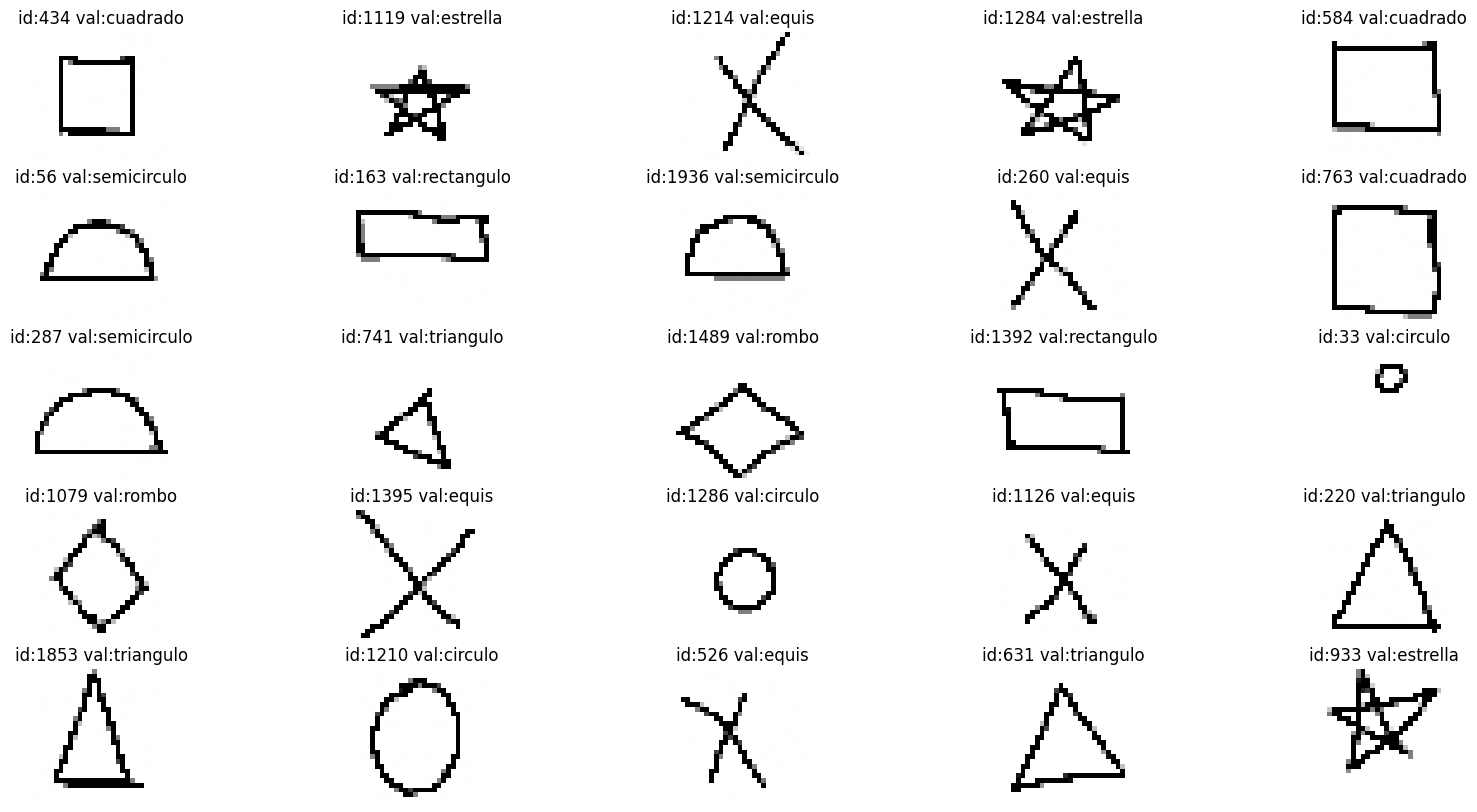

In [ ]:
# --- Visualización  ---
plt.figure(figsize=(20,10))
for i in range(25):
    plt.subplot(5,5, i+1)
    # Elegimos 25 índices aleatorios
    idx = np.random.choice(X_raw_like.shape[0], 1)[0]

    # Usamos el class_names_map que creamos
    plt.title('id:{} val:{}'.format(idx, class_names_map[y_custom[idx]] ))

    # Usamos X_raw_like[idx] que es (28, 28)
    plt.imshow(X_raw_like[idx], cmap='gray')
    plt.axis('off')
plt.show()

---

## 3. División Estratégica de Datos

Creamos dos conjuntos de entrenamiento diferentes para simular escenarios realistas:

### División Principal (80-20)
- **80% Entrenamiento completo**: Para Red A y Red B
- **20% Test**: Conjunto común para evaluar los 3 modelos

### División para Escasez
- **30% del entrenamiento**: Para Red C (simula escasez de datos)

Esta configuración nos permite comparar equitativamente los tres enfoques sobre el **mismo conjunto de prueba**.

In [ ]:
# 1. División Principal (80% Train, 20% Test) - Para Red A y B
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_raw_like, y_custom,
    test_size=0.20,
    random_state=SEED,
    stratify=y_custom
)

# 2. División para Escasez (30% de los datos de entrenamiento) - Para Red C
# Tomamos el X_train_full y extraemos solo un 30% para entrenar la Red C
X_train_30, _, y_train_30, _ = train_test_split(
    X_train_full, y_train_full,
    train_size=0.10,
    random_state=SEED,
    stratify=y_train_full
)

print(f"Datos Test (Para evaluar TODAS): {X_test.shape}")
print(f"Datos Train Full (Red A y B):    {X_train_full.shape} (100% de entrenamiento)")
print(f"Datos Train 30% (Red C):         {X_train_30.shape} (Simulando escasez)")

Datos Test (Para evaluar TODAS): (394, 28, 28, 1)
Datos Train Full (Red A y B):    (1575, 28, 28, 1) (100% de entrenamiento)
Datos Train 30% (Red C):         (157, 28, 28, 1) (Simulando escasez)


---

## 4. Arquitectura de la Red Neuronal

### Diseño de la CNN

Definimos una arquitectura convolucional estándar que será la base para los tres modelos:

```
Entrada (28x28x1)
    ↓
Conv2D(32) + ReLU + MaxPool
    ↓
Conv2D(64) + ReLU + MaxPool
    ↓
Conv2D(128) + ReLU + MaxPool
    ↓
Flatten
    ↓
Dense(128) + ReLU
    ↓
Dense(num_classes) + Softmax
```

**Características**:
- 3 bloques convolucionales con filtros crecientes (32→64→128)
- MaxPooling para reducción dimensional
- Capa densa intermedia de 128 neuronas
- Optimizador Adam con learning rate de 0.0001

In [ ]:
def build_model_from_reference(num_classes, input_shape=(28, 28, 1)):
    model = Sequential([
        Conv2D(32, 3, activation='relu', input_shape=input_shape),
        MaxPool2D(),
        Conv2D(64, 3, activation='relu', padding ='same'),
        MaxPool2D(),
        Conv2D(128, 3, activation='relu', padding ='same'),
        MaxPool2D(),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

---

## 5. Entrenamiento de los Modelos

### 5.1 Red B - Entrenamiento desde Cero (100% Datos)

**Configuración**:
- Datos: 100% del conjunto de entrenamiento
- Épocas: 50
- Batch size: 16
- Estrategia: Aprendizaje completo desde cero

Esta es nuestra **línea base óptima**, entrenada con todos los datos disponibles del dominio específico.

In [ ]:
print("\n--- Entrenando Red B (Desde Cero - 100% Datos) ---")
model_B = build_model_from_reference(NUM_CLASSES_CUSTOM, INPUT_SHAPE)

model_B.summary()
history_B = model_B.fit(
    X_train_full, y_train_full, # Usa el set completo
    epochs=50,
    batch_size=BATCH_SIZE_TRAIN,
    validation_data=(X_test, y_test),
    verbose=0 # Silencioso para no llenar la pantalla
)
print(f"Red B finalizada. Val Acc Final: {history_B.history['val_accuracy'][-1]:.4f}")


--- Entrenando Red B (Desde Cero - 100% Datos) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,288 (942.53 KB)

 Trainable params: 241,288 (942.53 KB)

 Non-trainable params: 0 (0.00 B)

Red B finalizada. Val Acc Final: 0.8909


### 5.2 Red C - Entrenamiento desde Cero (10% Datos - Escasez)

**Configuración**:
- Datos: Solo 30% del conjunto de entrenamiento
- Épocas: 50
- Batch size: 16
- Estrategia: Simula escenarios con **datos limitados**

Este modelo representa el peor caso: datos insuficientes sin conocimiento previo.

In [ ]:
print("\n--- Entrenando Red C (Desde Cero - 30% Datos) ---")
model_C = build_model_from_reference(NUM_CLASSES_CUSTOM, INPUT_SHAPE)

history_C = model_C.fit(
    X_train_30, y_train_30, # Usa el set reducido
    epochs=50,
    batch_size=BATCH_SIZE_TRAIN,
    validation_data=(X_test, y_test), # Evaluamos en el MISMO test set
    verbose=0
)
model_C.summary()
print(f"Red C finalizada. Val Acc Final: {history_C.history['val_accuracy'][-1]:.4f}")


--- Entrenando Red C (Desde Cero - 30% Datos) ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 723,866 (2.76 MB)

 Trainable params: 241,288 (942.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 482,578 (1.84 MB)

Red C finalizada. Val Acc Final: 0.8198


### 5.3 Red A - Transfer Learning (MNIST → Formas Geométricas)

**Estrategia de Transferencia**:

1. **Fase 1 - Preentrenamiento**:
   - Entrenar CNN en MNIST (números 0-9)
   - 5 épocas para aprender características básicas de imágenes 28x28

2. **Fase 2 - Transferencia**:
   - **Congelar capas convolucionales** (extracción de características)
   - **Descongelar capas densas** (clasificación específica)
   - Reemplazar capa de salida (10 → 8 clases)

3. **Fase 3 - Fine-tuning**:
   - Entrenar con 100% de datos de formas geométricas
   - 50 épocas

**Hipótesis**: El conocimiento de patrones básicos en MNIST (bordes, formas) ayudará a clasificar formas geométricas mejor que entrenar desde cero con datos escasos.

In [ ]:
print("\n--- Preparando Transfer Learning (Base MNIST) ---")
(mnist_X, mnist_y), (_, _) = mnist.load_data()
# Preprocesar MNIST
mnist_X = mnist_X[..., None] / 255.0
mnist_y = mnist_y.astype(int)

# Crear modelo base y entrenar con números
model_A_base = build_model_from_reference(num_classes=10, input_shape=INPUT_SHAPE)
model_A_base.fit(mnist_X, mnist_y, epochs=25, batch_size=32, verbose=0)
print("Modelo base MNIST entrenado.")

# --- Configurar Red A para Transferencia ---
model_A = Sequential()
for layer in model_A_base.layers[:-1]: # Copiar todo menos la capa final
    # Congelar extracción de características
    if isinstance(layer, (Conv2D, MaxPool2D)):
        layer.trainable = False
    else:
        layer.trainable = True # Dense intermedia se ajusta
    model_A.add(layer)

# Añadir nueva capa de salida para nuestras 8 formas
model_A.add(Dense(NUM_CLASSES_CUSTOM, activation='softmax', name='output_formas'))

model_A.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


--- Preparando Transfer Learning (Base MNIST) ---
Modelo base MNIST entrenado.


**Entrenamiento final de Red A** con las capas convolucionales congeladas y la nueva capa de salida.

In [ ]:
print("\n--- Ajustando Red A (Transfer MNIST + 100% Datos Propio) ---")
history_A = model_A.fit(
    X_train_full, y_train_full,
    epochs=50,
    batch_size=BATCH_SIZE_TRAIN,
    validation_data=(X_test, y_test),
    verbose=0
)
model_A.summary()
print(f"Red A finalizada. Val Acc Final: {history_A.history['val_accuracy'][-1]:.4f}")


--- Ajustando Red A (Transfer MNIST + 100% Datos Propio) ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_formas (Dense)           │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 538,522 (2.05 MB)

 Trainable params: 148,616 (580.53 KB)

 Non-trainable params: 92,672 (362.00 KB)

 Optimizer params: 297,234 (1.13 MB)

Red A finalizada. Val Acc Final: 0.8528


---

## 6. Análisis Comparativo de Resultados

### 6.1 Gráficas de Entrenamiento

Visualizamos la evolución del **accuracy** y **loss** durante las 50 épocas para los tres modelos.

**Qué observar**:
- **Red B (verde)**: Debería mostrar el mejor rendimiento general
- **Red A (azul)**: Convergencia más rápida que Red C gracias al transfer learning
- **Red C (rojo)**: Overfitting potencial por escasez de datos

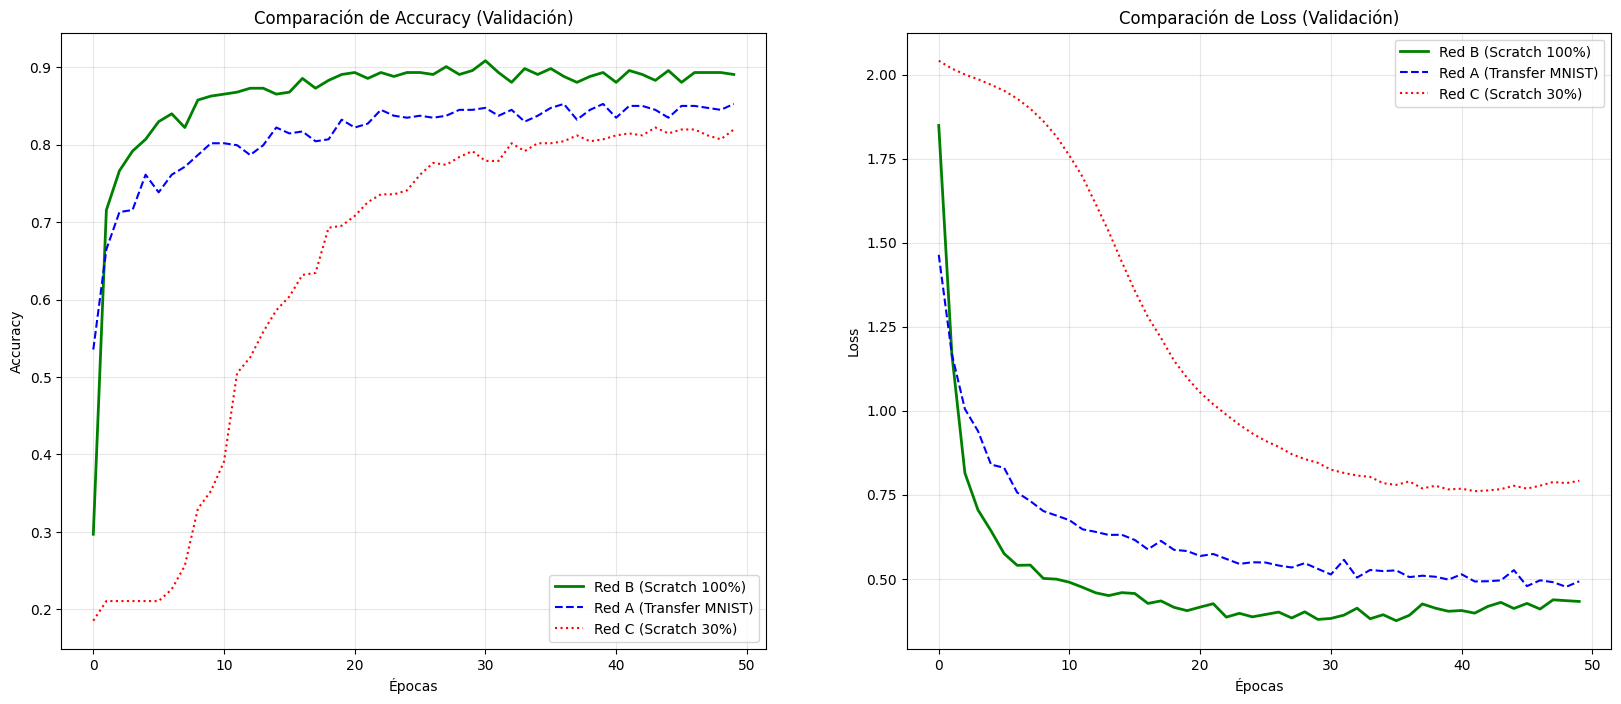

In [ ]:
plt.figure(figsize=(20, 8))

# 1. Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.title('Comparación de Accuracy (Validación)')
plt.plot(history_B.history['val_accuracy'], label='Red B (Scratch 100%)', color='green', linewidth=2)
plt.plot(history_A.history['val_accuracy'], label='Red A (Transfer MNIST)', color='blue', linestyle='--')
plt.plot(history_C.history['val_accuracy'], label='Red C (Scratch 30%)', color='red', linestyle=':')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()

# 2. Gráfica de Loss
plt.subplot(1, 2, 2)
plt.title('Comparación de Loss (Validación)')
plt.plot(history_B.history['val_loss'], label='Red B (Scratch 100%)', color='green', linewidth=2)
plt.plot(history_A.history['val_loss'], label='Red A (Transfer MNIST)', color='blue', linestyle='--')
plt.plot(history_C.history['val_loss'], label='Red C (Scratch 30%)', color='red', linestyle=':')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

### 6.2 Matrices de Confusión

Las matrices de confusión nos permiten identificar:
- **Clases bien clasificadas** (diagonal principal alta)
- **Confusiones comunes** entre clases similares
- **Diferencias de rendimiento** por clase entre modelos

**Interpretación**:
- Valores altos en la diagonal = buenas predicciones
- Valores fuera de la diagonal = errores de clasificación

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


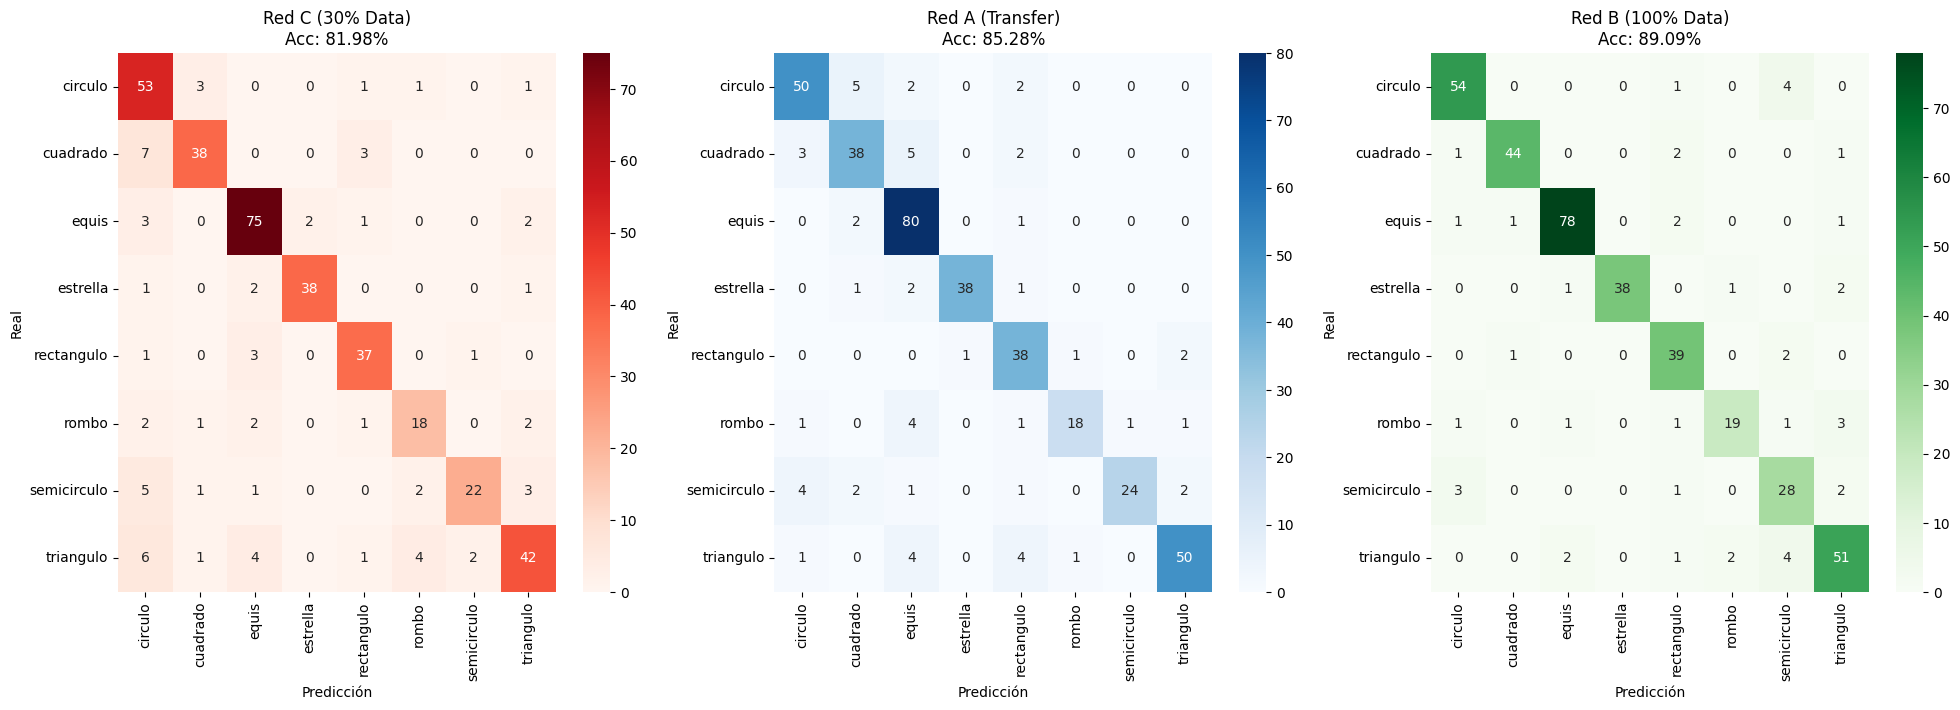

In [ ]:
# Obtener predicciones
y_pred_B = np.argmax(model_B.predict(X_test), axis=1)
y_pred_A = np.argmax(model_A.predict(X_test), axis=1)
y_pred_C = np.argmax(model_C.predict(X_test), axis=1)

target_names = list(class_names_map.values())

# Crear matrices
cm_B = confusion_matrix(y_test, y_pred_B)
cm_A = confusion_matrix(y_test, y_pred_A)
cm_C = confusion_matrix(y_test, y_pred_C)

# Graficar
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

sns.heatmap(cm_C, annot=True, fmt='d', cmap='Reds', ax=axes[0], xticklabels=target_names, yticklabels=target_names)
axes[0].set_title(f'Red C (30% Data)\nAcc: {history_C.history["val_accuracy"][-1]:.2%}')

sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', ax=axes[1], xticklabels=target_names, yticklabels=target_names)
axes[1].set_title(f'Red A (Transfer)\nAcc: {history_A.history["val_accuracy"][-1]:.2%}')

sns.heatmap(cm_B, annot=True, fmt='d', cmap='Greens', ax=axes[2], xticklabels=target_names, yticklabels=target_names)
axes[2].set_title(f'Red B (100% Data)\nAcc: {history_B.history["val_accuracy"][-1]:.2%}')

for ax in axes:
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.show()

### 6.3 Reportes de Clasificación Detallados

Evaluamos cada modelo con métricas estándar:

- **Precision**: De las predicciones de una clase, ¿cuántas fueron correctas?
- **Recall**: De todas las instancias de una clase, ¿cuántas se detectaron?
- **F1-Score**: Media armónica entre precision y recall
- **Support**: Número de muestras reales de cada clase

Estos reportes nos ayudan a identificar fortalezas y debilidades específicas por clase en cada modelo.

In [ ]:
# Reporte de Clasificación y Accuracy Final
print("Evaluando modelos en el conjunto de prueba (tus 8 formas)...")

# --- 1. Evaluación general (Loss y Accuracy) ---
score_C = model_C.evaluate(X_test, y_test, verbose=0) # Red C (30%)
score_A = model_A.evaluate(X_test, y_test, verbose=0) # Red A (Transfer)
score_B = model_B.evaluate(X_test, y_test, verbose=0) # Red B (100%)

print("\n--- Resultados Finales (Comparativa) ---")
# Orden sugerido: C (Peor) -> A (Medio) -> B (Mejor)
print(f"Red C (30% Data):       Accuracy = {score_C[1]*100:.2f}% | Loss = {score_C[0]:.4f}")
print(f"Red A (Transfer MNIST): Accuracy = {score_A[1]*100:.2f}% | Loss = {score_A[0]:.4f}")
print(f"Red B (100% Data):      Accuracy = {score_B[1]*100:.2f}% | Loss = {score_B[0]:.4f}")


# --- 2. Obtener predicciones (enteros) ---
print("\nGenerando predicciones para reportes detallados...")

# Predicciones Red C
y_pred_C_probs = model_C.predict(X_test)
y_pred_C = np.argmax(y_pred_C_probs, axis=1)

# Predicciones Red A
y_pred_A_probs = model_A.predict(X_test)
y_pred_A = np.argmax(y_pred_A_probs, axis=1)

# Predicciones Red B
y_pred_B_probs = model_B.predict(X_test)
y_pred_B = np.argmax(y_pred_B_probs, axis=1)

# Nombres de las clases para el reporte
target_names = list(class_names_map.values())


# --- 3. Imprimir Reportes de Clasificación ---

print("\n=========================================================")
print("      REPORTE DE CLASIFICACIÓN - RED C (Escasez - 30%)")
print("=========================================================")
print(classification_report(y_test, y_pred_C, target_names=target_names, zero_division=0))

print("\n=========================================================")
print("   REPORTE DE CLASIFICACIÓN - RED A (Transfer MNIST)")
print("=========================================================")
print(classification_report(y_test, y_pred_A, target_names=target_names, zero_division=0))

print("\n=========================================================")
print("      REPORTE DE CLASIFICACIÓN - RED B (Abundancia - 100%)")
print("=========================================================")
print(classification_report(y_test, y_pred_B, target_names=target_names, zero_division=0))

Evaluando modelos en el conjunto de prueba (tus 8 formas)...

--- Resultados Finales (Comparativa) ---
Red C (30% Data):       Accuracy = 81.98% | Loss = 0.7919
Red A (Transfer MNIST): Accuracy = 85.28% | Loss = 0.4929
Red B (100% Data):      Accuracy = 89.09% | Loss = 0.4330

Generando predicciones para reportes detallados...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

      REPORTE DE CLASIFICACIÓN - RED C (Escasez - 30%)
              precision    recall  f1-score   support

     circulo       0.68      0.90      0.77        59
    cuadrado       0.86      0.79      0.83        48
       equis       0.86      0.90      0.88        83
    estrella       0.95      0.90      0.93        42
  rectangulo       0.84      0.88      0.86        42
       rombo       0.72      0.69      0.71        26
 semicirculo       0.88      0.65      0.75        34
   triangulo       0.82      0.70      0.76        60

    acc

---

## 7. Conclusiones y Validación de Hipótesis

### Resumen Ejecutivo

Comparamos el accuracy final de los tres modelos y verificamos si se cumple nuestra hipótesis inicial:

**Hipótesis**: `Accuracy(C) < Accuracy(A) < Accuracy(B)`

### Interpretación Esperada

**Si la hipótesis se cumple**:
- El **Transfer Learning (Red A)** efectivamente mitiga la escasez de datos
- Los **datos nativos abundantes (Red B)** siguen siendo superiores
- La **escasez de datos (Red C)** limita severamente el rendimiento

**Si la hipótesis no se cumple**: Requiere análisis adicional de las gráficas y matrices de confusión para entender factores como overfitting, calidad de datos o problemas de convergencia.

In [ ]:
print("\n=== RESUMEN DE RESULTADOS ===")
acc_C = model_C.evaluate(X_test, y_test, verbose=0)[1]
acc_A = model_A.evaluate(X_test, y_test, verbose=0)[1]
acc_B = model_B.evaluate(X_test, y_test, verbose=0)[1]

print(f"1. Red C (Escasez - 30%):   {acc_C*100:.2f}%")
print(f"2. Red A (Transfer - MNIST):{acc_A*100:.2f}%")
print(f"3. Red B (Nativa - 100%):   {acc_B*100:.2f}%")

print("\nVerificación de Hipótesis (C < A < B):")
if acc_C < acc_A < acc_B:
    print("✅ HIPÓTESIS CUMPLIDA: El Transfer Learning ayudó a superar la escasez, pero los datos nativos completos son superiores.")
else:
    print("⚠️ RESULTADO INESPERADO: Revisar gráficas.")


=== RESUMEN DE RESULTADOS ===
1. Red C (Escasez - 30%):   81.98%
2. Red A (Transfer - MNIST):85.28%
3. Red B (Nativa - 100%):   89.09%

Verificación de Hipótesis (C < A < B):
✅ HIPÓTESIS CUMPLIDA: El Transfer Learning ayudó a superar la escasez, pero los datos nativos completos son superiores.
